In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn

In [2]:
print(f"Using the PyTorch version: {torch.__version__}")

## getting the device
device = "cuda" if torch.cuda.is_available() else 'cpu'
print(f"Device:{device}")

Using the PyTorch version: 2.8.0+cu128
Device:cuda


In [4]:
## setting seed for reproducibility
torch.manual_seed(42)

In [5]:
## Reading the data
df = pd.read_csv('/home/prashant/Documents/ML-DL/PyTorch/fashion-mnist_train.csv')
print('-'*5,'First 10 rows','-'*5,'\n')
display(df.head(10))
print(f'Shape of the FashionMNIST Dataset:{df.shape}')

----- First 10 rows ----- 



,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,5,4,5,5,3,5,...,7,8,7,4,3,7,5,0,0,0
6,4,0,0,0,0,0,0,0,0,0,...,14,0,0,0,0,0,0,0,0,0
7,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,3,2,0,...,1,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,203,214,166,0,0,0,0,0,0,0


Shape of the FashionMNIST Dataset:(60000, 785)


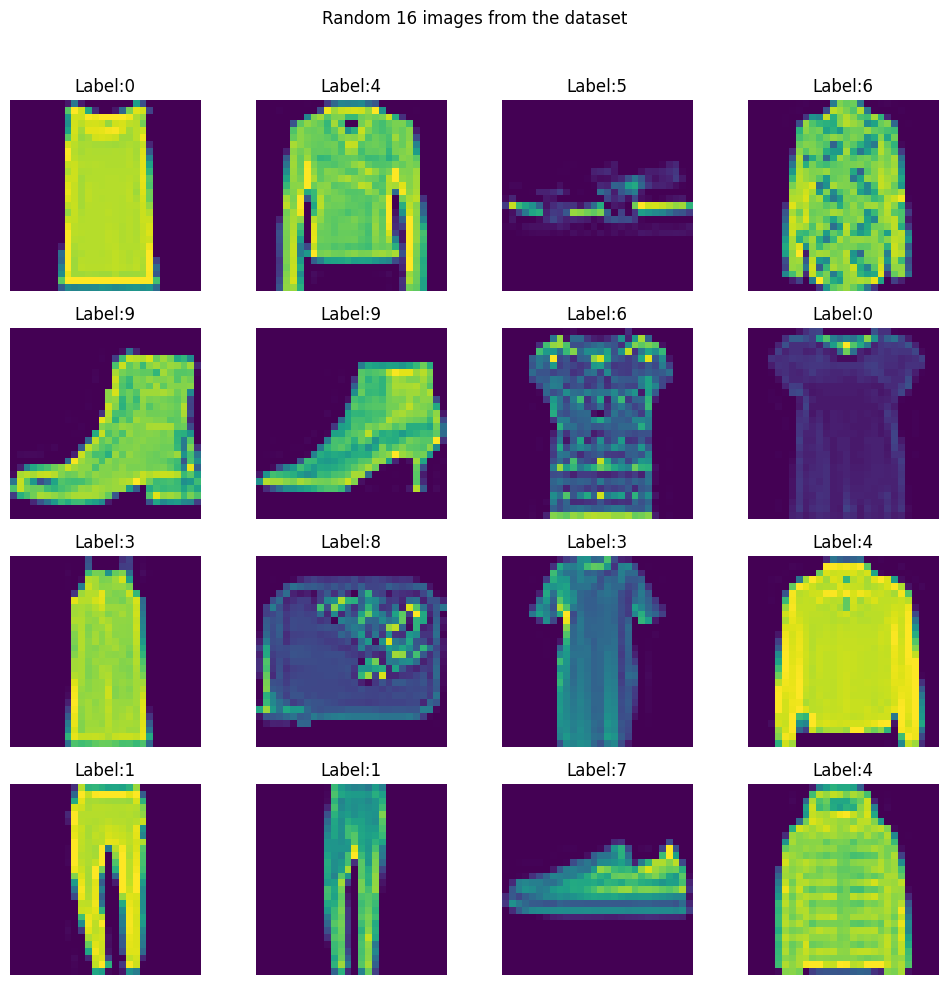

In [7]:
## Displaying few random datasets
fig, ax = plt.subplots(4,4,figsize=(10,10))
fig.suptitle('Random 16 images from the dataset', fontsize=12)

data = df.sample(16)

for i, axes in enumerate(ax.flatten()):
    image = data.iloc[i,1:].values.reshape(28,28)
    axes.imshow(image)
    axes.set_title(f"Label:{data.iloc[i,0]}")
    axes.axis('off')

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [8]:
## Train test split
X = df.drop('label', axis=1).values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

print(f"Shape of the splited data:\nX_train:{X_train.shape}\ny_train:{y_train.shape}\nX_test:{X_test.shape}\ny_test:{y_test.shape}")

Shape of the splited data:
X_train:(48000, 784)
y_train:(48000,)
X_test:(12000, 784)
y_test:(12000,)


In [9]:
## Applying Standardization
X_train = X_train / 255.0
X_test = X_test / 255.0

In [12]:
class FashionMNISTDataset(Dataset):
    # Constructor
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).reshape(-1,1,28,28)
        self.y = torch.tensor(y, dtype=torch.long)

    # Getting the length of the dataset
    def __len__(self):
        return len(self.X)
    
    # Getting a single item from the dataset
    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [13]:
train_set = FashionMNISTDataset(X_train, y_train)
test_set = FashionMNISTDataset(X_test, y_test)

In [14]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False, pin_memory=True)

In [15]:
## Model Building 

class FashionMNISTModel(nn.Module):

    def __init__(self, input_features):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            # First Layer
            nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Second Layer
            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, 10)
        )

    def forward(self, x):

        x = self.feature_extractor(x)
        x = self.classifier(x)

        return x

In [19]:
# Model Params
epochs = 100
learning_rate = 0.01

In [20]:
model = FashionMNISTModel(input_features=1).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [21]:
## Training loop

for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_X, batch_y in train_loader:

        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # Forward pass
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # update grads
        optimizer.step()

        total_epoch_loss += loss.item()

    avg_epoch_loss = total_epoch_loss / len(train_loader)
    print(f"Epoch:{epoch+1}/{epochs:<3}, Loss:{avg_epoch_loss:.4f}")

Epoch:1/100, Loss:0.6435
Epoch:2/100, Loss:0.3789
Epoch:3/100, Loss:0.3178
Epoch:4/100, Loss:0.2861
Epoch:5/100, Loss:0.2601
Epoch:6/100, Loss:0.2404
Epoch:7/100, Loss:0.2256
Epoch:8/100, Loss:0.2103
Epoch:9/100, Loss:0.1967
Epoch:10/100, Loss:0.1879
Epoch:11/100, Loss:0.1789
Epoch:12/100, Loss:0.1637
Epoch:13/100, Loss:0.1581
Epoch:14/100, Loss:0.1510
Epoch:15/100, Loss:0.1388
Epoch:16/100, Loss:0.1315
Epoch:17/100, Loss:0.1233
Epoch:18/100, Loss:0.1223
Epoch:19/100, Loss:0.1129
Epoch:20/100, Loss:0.1079
Epoch:21/100, Loss:0.1028
Epoch:22/100, Loss:0.0977
Epoch:23/100, Loss:0.0923
Epoch:24/100, Loss:0.0912
Epoch:25/100, Loss:0.0829
Epoch:26/100, Loss:0.0792
Epoch:27/100, Loss:0.0774
Epoch:28/100, Loss:0.0765
Epoch:29/100, Loss:0.0733
Epoch:30/100, Loss:0.0696
Epoch:31/100, Loss:0.0659
Epoch:32/100, Loss:0.0629
Epoch:33/100, Loss:0.0576
Epoch:34/100, Loss:0.0583
Epoch:35/100, Loss:0.0573
Epoch:36/100, Loss:0.0550
Epoch:37/100, Loss:0.0532
Epoch:38/100, Loss:0.0490
Epoch:39/100, Loss:0.

In [ ]:
model.eval()

# Evaluation loop on test data

total_correct = 0
total_samples = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:

        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        y_pred = model(batch_X)
        _, predicted_labels = torch.max(y_pred, 1)

        total_samples = total_samples + batch_y.shape[0]

        total_correct += (predicted_labels == batch_y).sum().item()

accuracy = total_correct / total_samples * 100
print(f"Test Accuracy:{accuracy:.4f}")

Test Accuracy:92.3833


In [23]:
model.eval()

# Evaluation loop on test data

total_correct = 0
total_samples = 0

with torch.no_grad():
    for batch_X, batch_y in train_loader:

        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        y_pred = model(batch_X)
        _, predicted_labels = torch.max(y_pred, 1)

        total_samples = total_samples + batch_y.shape[0]

        total_correct += (predicted_labels == batch_y).sum().item()

accuracy = total_correct / total_samples * 100
print(f"Test Accuracy:{accuracy:.4f}")

Test Accuracy:99.9458
